<a href="https://colab.research.google.com/github/mhabibier/scikit-learn-cookbook/blob/main/07_Support_Vector_Machines_and_Kernel_Methods.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 7 — Support Vector Machines and Kernel Methods

**scikit-learn Cookbook, Third Edition — John Sukup (Packt, 2025)**  
**Nama:** Muhammad Habibie Rabbani · **Kelas:** TK-47-04

## Tujuan pembelajaran
Memahami margin, support vectors, kernel, pengaruh C/gamma, klasifikasi berdimensi tinggi, dan evaluasi SVM. Membedakan tujuan SVC dan SVR serta menggunakan CV tanpa kebocoran preprocessing.

## Peta reproduksi
Notebook ini mengadaptasi notebook bab utama dan *Exercise Solutions* dari [kode pendamping resmi](https://github.com/PacktPublishing/scikit-learn-Cookbook-Third-Edition/tree/c624b1279cf23a83273e806cede15cad0c9e5500), commit `c624b1279cf23a83273e806cede15cad0c9e5500`. Penjelasan ditulis ulang dalam Bahasa Indonesia; kode disesuaikan agar dapat dijalankan pada lingkungan yang dicatat di bawah. Penomoran bagian mengikuti alur konsep sumber, bukan nomor halaman PDF. Buku tetap referensi utama untuk membaca uraian lengkap.

| Resep sumber | Bagian |
|---|---|
| Introduction to SVMs (SVC dan SVR) | 1–2 |
| Kernel functions and applications | 3 |
| Tuning SVM parameters | 4 |
| High-dimensional spaces | 5 |
| Evaluating SVM models | 6 |
| Exercises 1–3 | 2 (Iris), 6 (Cancer grid), 7 (boundary sintetis) |

## Penyesuaian dan batas reproduksi
Dataset dan seed klasifikasi mengikuti sumber dengan tambahan stratifikasi dan scaler di dalam Pipeline. Sumber memperlakukan kode kelas Iris sebagai target SVR; di sini **SVR memakai target kontinu Diabetes** agar makna regresinya benar. Degree hanya dicari untuk kernel polynomial. PCA hanya fit pada training. Grafik batas keputusan berasal dari model dua fitur yang benar-benar dilatih, bukan proyeksi model empat fitur dengan fitur lain diisi nol.

## Cara menjalankan
Jalankan **Restart Kernel → Run All** dari atas ke bawah. Setiap notebook mandiri. Gunakan Python 3.12 dan paket dalam `requirements.txt`; versi yang benar-benar dipakai tampil di sel pertama. Dataset tersedia melalui scikit-learn atau generator sintetis; tidak memerlukan unduhan data tambahan setelah paket terpasang.

Untuk Google Colab: unggah `.ipynb`, instal versi paket yang diperlukan bila berbeda, lalu **Restart session → Run all**. Pengujian paket ini dilakukan dengan proses IPython baru per notebook, bukan melalui antarmuka Colab.

In [1]:
%matplotlib inline
import sys, platform, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
from IPython.display import display, Markdown
from sklearn.base import clone
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, GridSearchCV
from sklearn.metrics import accuracy_score, balanced_accuracy_score, classification_report, f1_score

SEED = 2024
np.random.seed(SEED)
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'figure.figsize': (8, 4.5), 'figure.dpi': 115, 'axes.titlesize': 12})
pd.set_option('display.max_columns', 16)
pd.set_option('display.precision', 4)
print({'Python': platform.python_version(), 'scikit-learn': sklearn.__version__,
       'NumPy': np.__version__, 'pandas': pd.__version__, 'seed': SEED})

def audit_numeric(X, y=None, name='data'):
    frame = pd.DataFrame(X)
    print(name, {'shape': frame.shape, 'missing': int(frame.isna().sum().sum()),
                 'duplicate_rows': int(frame.duplicated().sum()),
                 'all_finite': bool(np.isfinite(frame.to_numpy(dtype=float)).all())})
    if y is not None and np.asarray(y).ndim == 1:
        display(pd.Series(y).value_counts().sort_index().rename('jumlah').to_frame())

def report(y_true, y_pred, names=None):
    result = classification_report(y_true, y_pred, target_names=names, output_dict=True, zero_division=0)
    overall_accuracy = result.pop('accuracy', None)
    display(pd.DataFrame(result).T)
    if overall_accuracy is not None:
        print(f'Overall accuracy: {overall_accuracy:.4f} (n={len(y_true)})')

def metrics(y_true, y_pred):
    return {'accuracy': accuracy_score(y_true, y_pred),
            'balanced_accuracy': balanced_accuracy_score(y_true, y_pred),
            'macro_f1': f1_score(y_true, y_pred, average='macro', zero_division=0)}

{'Python': '3.13.16', 'scikit-learn': '1.6.1', 'NumPy': '2.1.3', 'pandas': '2.2.3', 'seed': 2024}


## 1. Teori SVM dan pemisahan data
SVM mencari hyperplane $w^Tx+b=0$ yang memisahkan kelas dengan margin besar. Untuk label $y_i\in\{-1,+1\}$, soft-margin SVM dapat ditulis:
$$\min_{w,b,\xi}\ \frac12\|w\|^2+C\sum_i\xi_i,\qquad y_i(w^Tx_i+b)\geq1-\xi_i,\quad\xi_i\geq0.$$
Margin geometris antara dua bidang penyangga adalah $2/\|w\|$. Support vectors adalah observasi yang menentukan solusi melalui koefisien dual nonnol. **C kecil** lebih menerima pelanggaran margin; C besar lebih menghukum kesalahan training dan dapat meningkatkan sensitivitas terhadap noise. Margin besar tidak menjamin tidak ada kesalahan.

SVM sensitif terhadap skala karena jarak dan dot product berubah ketika satuan fitur berubah. StandardScaler harus dipelajari pada training, termasuk di setiap fold CV. Pada multiclass, `SVC` melatih classifier pairwise (OvO) secara internal; bentuk skor keluaran default OvR tidak mengubah strategi pelatihan tersebut. Benchmark kecil tidak mewakili data operasional dengan shift distribusi.

In [2]:
from sklearn.datasets import load_iris, load_diabetes, load_breast_cancer, make_classification
from sklearn.svm import SVC, SVR
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score, RocCurveDisplay, roc_auc_score
from sklearn.dummy import DummyClassifier, DummyRegressor
from sklearn.decomposition import PCA
iris=load_iris()
audit_numeric(iris.data,iris.target,'Iris')
Xt,Xv,yt,yv=train_test_split(iris.data,iris.target,test_size=.3,stratify=iris.target,random_state=SEED)
cv=StratifiedKFold(5,shuffle=True,random_state=SEED)
linear=make_pipeline(StandardScaler(),SVC(kernel='linear',C=1,random_state=SEED)).fit(Xt,yt)
baseline=DummyClassifier(strategy='most_frequent').fit(Xt,yt)
display(pd.DataFrame({'Dummy':metrics(yv,baseline.predict(Xv)),'Linear SVC':metrics(yv,linear.predict(Xv))}).T)
print('Support vectors per kelas:',linear[-1].n_support_)
report(yv,linear.predict(Xv),list(iris.target_names))

Iris {'shape': (150, 4), 'missing': 0, 'duplicate_rows': 1, 'all_finite': True}


,jumlah
0,50
1,50
2,50


,accuracy,balanced_accuracy,macro_f1
Dummy,0.3333,0.3333,0.1667
Linear SVC,0.9778,0.9778,0.9778


Support vectors per kelas: [ 2 10  9]


,precision,recall,f1-score,support
setosa,1.0000,1.0000,1.0000,15.0
versicolor,1.0000,0.9333,0.9655,15.0
virginica,0.9375,1.0000,0.9677,15.0
macro avg,0.9792,0.9778,0.9778,45.0
weighted avg,0.9792,0.9778,0.9778,45.0


Overall accuracy: 0.9778 (n=45)


## 2. Latihan 1 dan SVR untuk target kontinu
Sel sebelumnya menyelesaikan **Latihan 1: simple SVM classifier pada Iris**. Sel berikut memperlihatkan training-CV sebagai informasi tambahan dan menjalankan regresi yang sesuai tipe target.

SVR memakai tabung $\epsilon$ di sekitar fungsi regresi: residual dengan besar tidak melebihi $\epsilon$ tidak terkena epsilon-insensitive loss. $C$ mengendalikan penalti residual di luar tabung. Tidak ada probabilitas kelas pada SVR.

Kode kelas Iris 0/1/2 hanyalah identitas spesies, sehingga MSE atas kode itu bergantung pada penomoran arbitrer. Diabetes menyediakan respons kuantitatif yang lebih tepat. RMSE dan MAE diukur pada satuan target, sedangkan $R^2$ membandingkan terhadap prediksi rata-rata test dan dapat bernilai negatif. `DummyRegressor` dilatih dengan rata-rata training.

Latihan 1 training-CV accuracy: [1.         1.         1.         0.95238095 0.95238095]


,model,RMSE,MAE,R2
0,Mean baseline,78.1758,66.1455,-1.8480e-05
1,RBF SVR,55.2225,42.1295,5.0101e-01


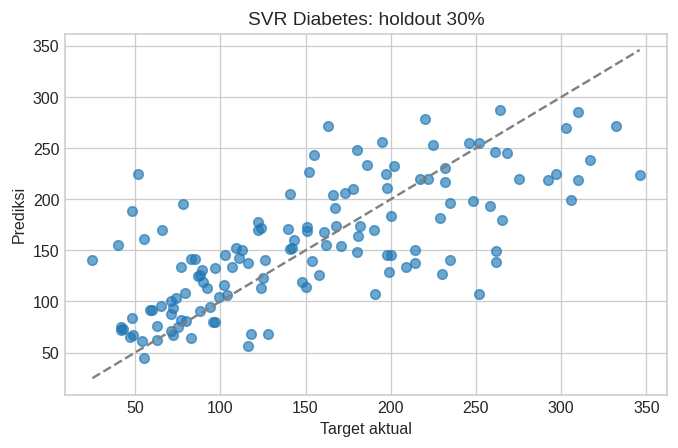

In [3]:
print('Latihan 1 training-CV accuracy:',cross_validate(clone(linear),Xt,yt,cv=cv,scoring='accuracy')['test_score'])
d=load_diabetes()
Dt,Dv,dt,dv=train_test_split(d.data,d.target,test_size=.3,random_state=SEED)
reg=make_pipeline(StandardScaler(),SVR(kernel='rbf',C=100,epsilon=10)).fit(Dt,dt)
dr=DummyRegressor().fit(Dt,dt)
rows=[]
for name,m in [('Mean baseline',dr),('RBF SVR',reg)]:
    p=m.predict(Dv)
    rows.append({'model':name,'RMSE':root_mean_squared_error(dv,p),'MAE':mean_absolute_error(dv,p),'R2':r2_score(dv,p)})
display(pd.DataFrame(rows))
fig,ax=plt.subplots(figsize=(6,4))
ax.scatter(dv,reg.predict(Dv),alpha=.65); lo,hi=dv.min(),dv.max(); ax.plot([lo,hi],[lo,hi],'--',color='gray')
ax.set(xlabel='Target aktual',ylabel='Prediksi',title='SVR Diabetes: holdout 30%')
plt.tight_layout(); plt.show()

## 3. Kernel dan bentuk decision boundary
Kernel menghitung kemiripan pada ruang fitur implisit, tanpa selalu membentuk semua fitur secara eksplisit:

| Kernel | Rumus | Pengaruh |
|---|---|---|
| Linear | $K(x,z)=x^Tz$ | Batas linear pada ruang fitur input |
| Polynomial | $(\gamma x^Tz+r)^d$ | Interaksi sampai derajat d; sensitif skala |
| RBF | $\exp(-\gamma\|x-z\|^2)$ | Batas lokal nonlinear |

Gamma besar membuat pengaruh setiap sampel lebih lokal, sehingga batas dapat sangat berliku. Gamma kecil memberi pengaruh lebih luas. Derajat tinggi bukan otomatis lebih baik. Grafik dua fitur di bawah memakai dua fitur sepal agar kelas tidak terpisah sempurna; model untuk grafik berbeda dari classifier empat fitur pada tabel. Angka pada tabel adalah evaluasi model yang sudah ditentukan, bukan prosedur memilih pemenang menggunakan test.

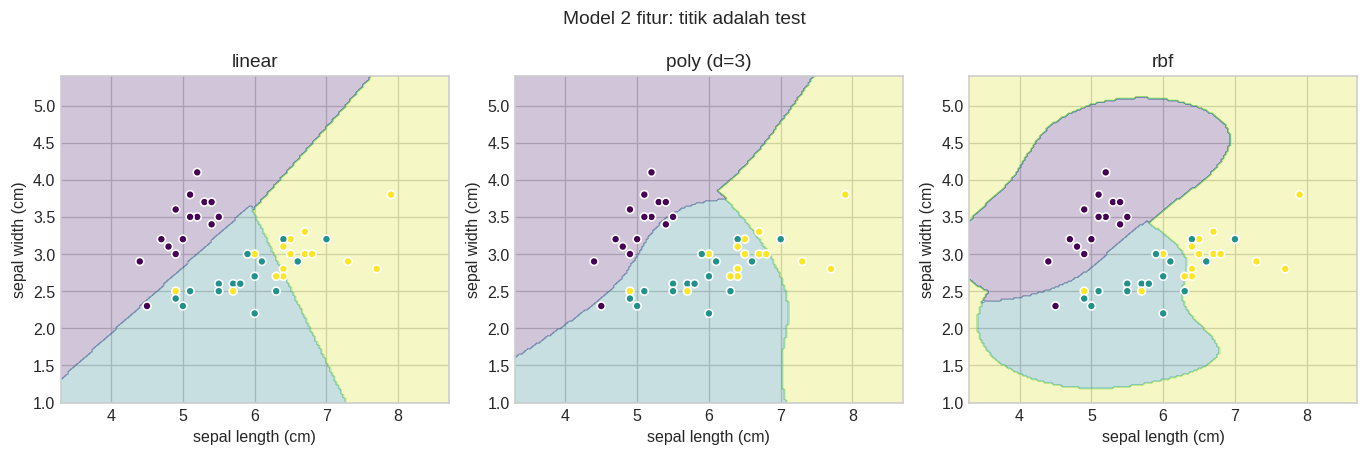

,kernel,accuracy,balanced_accuracy,macro_f1
0,linear,0.9778,0.9778,0.9778
1,poly (d=3),0.8889,0.8889,0.8857
2,rbf,0.9333,0.9333,0.9333


In [4]:
kernels={'linear':SVC(kernel='linear'), 'poly (d=3)':SVC(kernel='poly',degree=3), 'rbf':SVC(kernel='rbf')}
kernel_rows=[]
fig,axes=plt.subplots(1,3,figsize=(12,4))
for ax,(name,est) in zip(axes,kernels.items()):
    full=make_pipeline(StandardScaler(),clone(est)).fit(Xt,yt)
    kernel_rows.append({'kernel':name,**metrics(yv,full.predict(Xv))})
    visual=make_pipeline(StandardScaler(),clone(est)).fit(Xt[:,:2],yt)
    DecisionBoundaryDisplay.from_estimator(visual,Xt[:,:2],response_method='predict',grid_resolution=180,alpha=.25,ax=ax,cmap='viridis')
    ax.scatter(Xv[:,0],Xv[:,1],c=yv,cmap='viridis',edgecolors='white',s=25)
    ax.set(title=name,xlabel=iris.feature_names[0],ylabel=iris.feature_names[1])
plt.suptitle('Model 2 fitur: titik adalah test'); plt.tight_layout(); plt.show()
display(pd.DataFrame(kernel_rows))

## 4. Tuning C, gamma dan degree
`GridSearchCV` melatih kandidat pada training-fold dan mengukur validation-fold. `best_score_` adalah hasil CV untuk memilih model, **bukan** estimasi bebas bias setelah mencoba banyak kandidat. Test akhir disisihkan. Grid berupa list of dictionaries menghindari `degree` yang tidak berpengaruh pada linear/RBF. Split CV dibuat eksplisit dan diacak dengan seed.

Kurva C memperlihatkan rata-rata serta simpangan baku skor antar-fold. Area ini bukan confidence interval formal karena fold saling bergantung. C yang memperbaiki training tetapi tidak CV mengindikasikan tambahan kompleksitas tidak memberi manfaat generalisasi.

Best parameters: {'svc__C': 1, 'svc__kernel': 'linear'} ; mean CV: 0.980952380952381
Final Iris test: {'accuracy': 0.9777777777777777, 'balanced_accuracy': np.float64(0.9777777777777779), 'macro_f1': 0.9777530589543938}


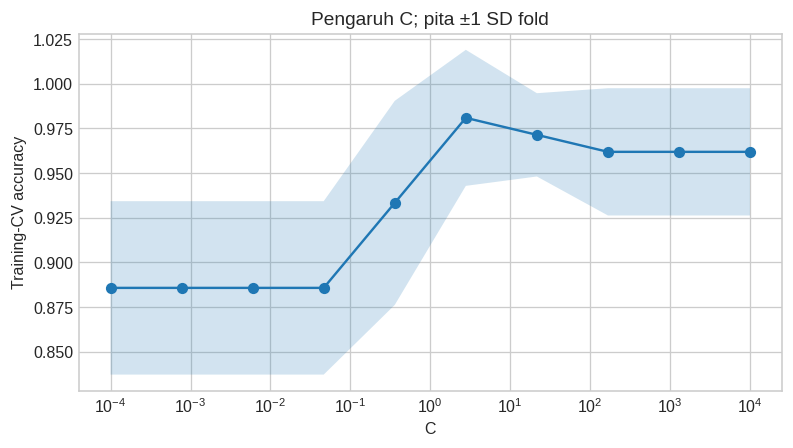

In [5]:
grid=[{'svc__kernel':['linear'],'svc__C':[.1,1,10]},
      {'svc__kernel':['rbf'],'svc__C':[.1,1,10],'svc__gamma':['scale',.01,.1]},
      {'svc__kernel':['poly'],'svc__C':[.1,1,10],'svc__degree':[2,3,4]}]
search=GridSearchCV(make_pipeline(StandardScaler(),SVC()),grid,cv=cv,scoring='accuracy',n_jobs=1,error_score='raise').fit(Xt,yt)
print('Best parameters:',search.best_params_,'; mean CV:',search.best_score_)
print('Final Iris test:',metrics(yv,search.predict(Xv)))
Cs=np.logspace(-4,4,10)
curve=GridSearchCV(make_pipeline(StandardScaler(),SVC(kernel='rbf')),{'svc__C':Cs},cv=cv,scoring='accuracy',n_jobs=1).fit(Xt,yt)
results=pd.DataFrame(curve.cv_results_)
mean=results.mean_test_score.to_numpy(); std=results.std_test_score.to_numpy()
fig,ax=plt.subplots(figsize=(7,4)); ax.semilogx(Cs,mean,'o-'); ax.fill_between(Cs,mean-std,mean+std,alpha=.2)
ax.set(xlabel='C',ylabel='Training-CV accuracy',title='Pengaruh C; pita ±1 SD fold')
plt.tight_layout(); plt.show()

## 5. SVM pada ruang berdimensi tinggi
Resep menggunakan 1.000 sampel, 1.000 fitur, dan hanya 50 fitur informatif. Banyak fitur tidak menjamin banyak informasi; noise dan rasio fitur terhadap sampel memengaruhi generalisasi. SVC linear dapat bekerja pada dimensi tinggi, tetapi kernel SVC menjadi mahal saat jumlah sampel membesar. `LinearSVC` atau `SGDClassifier` sering lebih cocok untuk data sangat besar, dengan objective/solver yang tidak identik.

PCA dua komponen di bawah hanya untuk visualisasi dan fit pada training. Model SVC tetap memakai seluruh 1.000 fitur. Dua warna yang saling tumpang tindih pada gambar tidak membuktikan data tidak dapat dipisahkan di ruang berdimensi tinggi. Varians yang tersimpan pada dua PC dicetak agar kehilangan informasi terlihat.

High-dimensional test: {'accuracy': 0.58, 'balanced_accuracy': np.float64(0.5798035468243032), 'macro_f1': 0.5795328142380423}
Training accuracy: 1.0 Support vectors: 523
Explained variance 2 PC: 0.00954752095053498


**Diagnosis eksperimen:** training accuracy 1.000 dan test accuracy 0.580. Gap besar menunjukkan model pada konfigurasi ini gagal menggeneralisasi dengan baik. Tuning regularisasi atau seleksi fitur harus dirancang melalui training-CV pada eksperimen lanjutan; test ini tidak dipakai untuk mengejar skor yang lebih tinggi.

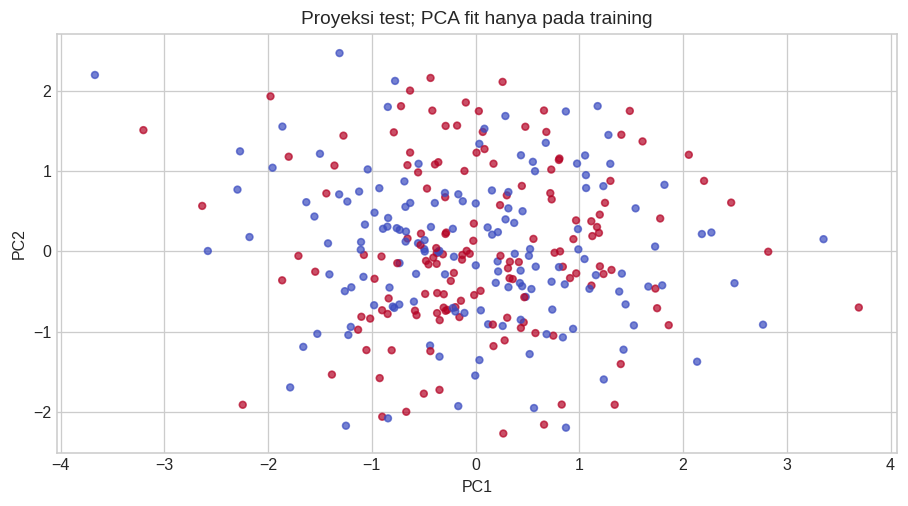

In [6]:
Xh,yh=make_classification(n_samples=1000,n_features=1000,n_informative=50,n_redundant=0,random_state=SEED)
Ht,Hv,ht,hv=train_test_split(Xh,yh,test_size=.3,stratify=yh,random_state=SEED)
high=make_pipeline(StandardScaler(),SVC(kernel='linear',C=1)).fit(Ht,ht)
print('High-dimensional test:',metrics(hv,high.predict(Hv)))
print('Training accuracy:',high.score(Ht,ht),'Support vectors:',high[-1].n_support_.sum())
visual_pca=make_pipeline(StandardScaler(),PCA(n_components=2,svd_solver='randomized',random_state=SEED)).fit(Ht)
H2=visual_pca.transform(Hv)
print('Explained variance 2 PC:',visual_pca[-1].explained_variance_ratio_.sum())
display(Markdown(f'**Diagnosis eksperimen:** training accuracy {high.score(Ht,ht):.3f} dan test accuracy {high.score(Hv,hv):.3f}. '
    'Gap besar menunjukkan model pada konfigurasi ini gagal menggeneralisasi dengan baik. '
    'Tuning regularisasi atau seleksi fitur harus dirancang melalui training-CV pada eksperimen lanjutan; test ini tidak dipakai untuk mengejar skor yang lebih tinggi.'))
fig,ax=plt.subplots(); ax.scatter(H2[:,0],H2[:,1],c=hv,cmap='coolwarm',s=18,alpha=.7)
ax.set(xlabel='PC1',ylabel='PC2',title='Proyeksi test; PCA fit hanya pada training')
plt.tight_layout(); plt.show()

## 6. Evaluasi Breast Cancer dan Latihan 2
Latihan 2 menala SVM pada Breast Cancer. Pipeline scaling dipasang di dalam grid; menghitung scaler pada seluruh data sebelum grid akan membocorkan informasi validation-fold. Kita memilih kandidat melalui **balanced accuracy** agar kontribusi malignant dan benign seimbang.

Untuk ROC gunakan `decision_function`: skor bertanda positif di SVC biner mengarah ke `classes_[1]` (benign). Kita membalik tandanya untuk malignant = 0. Skor margin bukan probabilitas. Jika membutuhkan probabilitas terkalibrasi, gunakan kalibrasi dengan data terpisah/CV dan evaluasi kalibrasinya. Menyetel `probability=True` menambah fitting kalibrasi internal dan tidak diperlukan hanya untuk menghitung ROC-AUC.

Cancer training {'shape': (398, 30), 'missing': 0, 'duplicate_rows': 0, 'all_finite': True}


,jumlah
0,148
1,250


Latihan 2 best: {'svc__C': 10, 'svc__gamma': 0.01, 'svc__kernel': 'rbf'} CV balanced accuracy: 0.9811034482758622


,precision,recall,f1-score,support
malignant,0.9531,0.9531,0.9531,64.0
benign,0.9720,0.9720,0.9720,107.0
macro avg,0.9625,0.9625,0.9625,171.0
weighted avg,0.9649,0.9649,0.9649,171.0


Overall accuracy: 0.9649 (n=171)


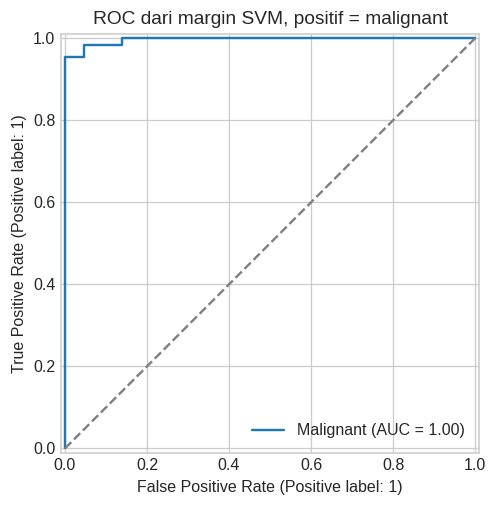

**Hasil:** balanced accuracy test = 0.963, ROC-AUC = 0.996. Selisih CV dan test menunjukkan variasi sampel; performa ini tidak memvalidasi penggunaan klinis.

In [7]:
cancer=load_breast_cancer()
Ct,Cv,ct,cv_y=train_test_split(cancer.data,cancer.target,test_size=.3,stratify=cancer.target,random_state=SEED)
audit_numeric(Ct,ct,'Cancer training')
cancer_search=GridSearchCV(make_pipeline(StandardScaler(),SVC()),grid,cv=cv,scoring='balanced_accuracy',n_jobs=1,error_score='raise').fit(Ct,ct)
cp=cancer_search.predict(Cv)
print('Latihan 2 best:',cancer_search.best_params_,'CV balanced accuracy:',cancer_search.best_score_)
report(cv_y,cp,list(cancer.target_names))
assert np.array_equal(cancer_search.classes_,[0,1])
malignant_scores=-cancer_search.decision_function(Cv)
cancer_auc=roc_auc_score(cv_y==0,malignant_scores)
fig,ax=plt.subplots(); RocCurveDisplay.from_predictions(cv_y==0,malignant_scores,ax=ax,name='Malignant'); ax.plot([0,1],[0,1],'--',color='gray')
ax.set(title='ROC dari margin SVM, positif = malignant'); plt.tight_layout(); plt.show()
display(Markdown(f'**Hasil:** balanced accuracy test = {balanced_accuracy_score(cv_y,cp):.3f}, ROC-AUC = {cancer_auc:.3f}. '
 'Selisih CV dan test menunjukkan variasi sampel; performa ini tidak memvalidasi penggunaan klinis.'))

## 7. Latihan 3 — boundary RBF pada data sintetis
Kedua fitur bersifat informatif dan tidak ada fitur redundan. Plot menunjukkan prediksi model di grid serta titik test; label test dipakai untuk penilaian setelah fitting. Support vectors ditunjukkan dari training. Tidak ada jaminan semua support vectors salah diklasifikasikan: titik di margin atau di dalam margin juga dapat menjadi support vector.

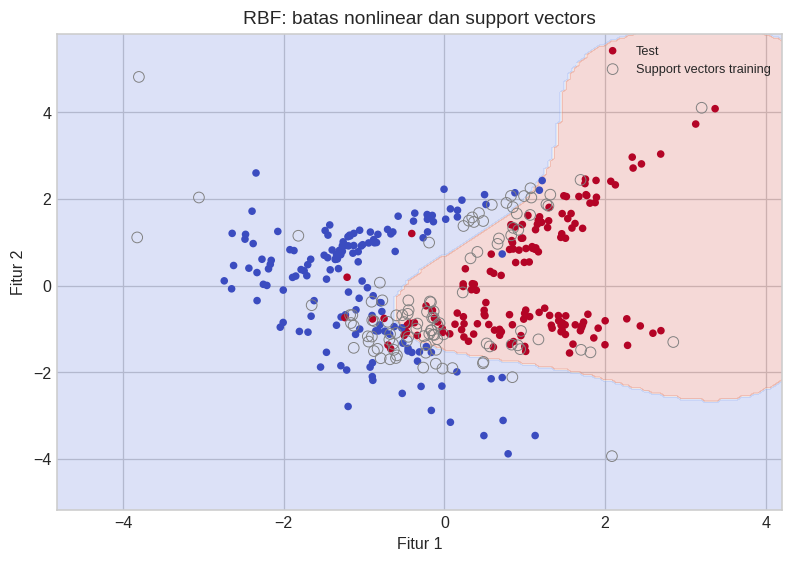

Latihan 3 test: {'accuracy': 0.96, 'balanced_accuracy': np.float64(0.9600871149828881), 'macro_f1': 0.9599982221432064}


In [8]:
Xs,ys=make_classification(n_samples=1000,n_features=2,n_informative=2,n_redundant=0,random_state=SEED)
St,Sv,st,sv=train_test_split(Xs,ys,test_size=.3,stratify=ys,random_state=SEED)
rbf=make_pipeline(StandardScaler(),SVC(kernel='rbf')).fit(St,st)
fig,ax=plt.subplots(figsize=(7,5))
DecisionBoundaryDisplay.from_estimator(rbf,St,response_method='predict',grid_resolution=180,alpha=.2,ax=ax,cmap='coolwarm')
ax.scatter(Sv[:,0],Sv[:,1],c=sv,cmap='coolwarm',s=14,label='Test')
support=St[rbf[-1].support_]
ax.scatter(support[:,0],support[:,1],s=45,facecolors='none',edgecolors='gray',linewidths=.6,label='Support vectors training')
ax.set(xlabel='Fitur 1',ylabel='Fitur 2',title='RBF: batas nonlinear dan support vectors'); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()
print('Latihan 3 test:',metrics(sv,rbf.predict(Sv)))

## Ringkasan chapter
SVM menyeimbangkan margin dan pelanggaran melalui C. Kernel mengubah geometri model; gamma/degree mengendalikan fleksibilitas dan perlu dipilih memakai training-CV. Scaling adalah bagian model yang wajib ikut divalidasi. SVC memprediksi kelas, SVR memprediksi target kontinu, sedangkan PCA dua dimensi hanya alat visualisasi pada eksperimen dimensi tinggi.

## Refleksi untuk dikerjakan sendiri
1. Mengapa C besar dan gamma besar dapat menghasilkan batas yang terlalu mengikuti noise?
2. Mengapa ROC bisa dihitung dari margin tanpa `predict_proba`?
3. Jelaskan mengapa MSE pada kode spesies Iris tidak layak dipakai sebagai ukuran regresi ilmiah.
4. Bandingkan biaya komputasi ketika jumlah fitur bertambah dan ketika jumlah sampel bertambah.

## Referensi dan atribusi
- John Sukup. *scikit-learn Cookbook*, Third Edition. Packt Publishing, 2025. Kode pendamping Chapter 7 dan solusi latihan: [repository resmi](https://github.com/PacktPublishing/scikit-learn-Cookbook-Third-Edition/tree/c624b1279cf23a83273e806cede15cad0c9e5500).
- [Support vector machines](https://scikit-learn.org/1.8/modules/svm.html).
- [GridSearchCV](https://scikit-learn.org/1.8/modules/generated/sklearn.model_selection.GridSearchCV.html).
- [Common pitfalls: leakage](https://scikit-learn.org/1.8/common_pitfalls.html).
- Kode sumber pendamping berlisensi MIT; teks lisensi dipertahankan pada `THIRD_PARTY_NOTICES.md`. Penjelasan, koreksi metodologi, dan eksperimen tambahan pada notebook ini merupakan adaptasi belajar berbantuan AI. Baca, jalankan ulang, dan tulis refleksi pribadi sebelum menyerahkan tugas; jangan menyatakan bagian berbantuan AI sebagai pekerjaan mandiri tanpa mengikuti kebijakan kelas.